---
title: Do SOTA architectures exploit SST information?
authors:
  - Marco Betschart
exports:
  - format: pdf
    template: arxiv_two_column
    output: exports/SOTA-of-SST-Exploitation.pdf
---

In [1]:
import plots

# Abstract

Temporal information in audio signals are important cues for humans in speaker recognition tasks @doi:10.1145/1631272.1631300.
Surprisingly, exploitation of temporal information by neural network algorithms has been shown to be lacking - even for recent architectures @doi:10.1016/j.patrec.2024.03.016. Therefore, this work investigates the amount of temporal information exploited by a Conformer neural network architecture @doi:10.48550/arXiv.2005.08100, which is the current state-of-the-art neural network architecture for audio signal processing.

# Introduction

Back in 2009, @doi:10.1145/1631272.1631300 evaluated human performance on a Speaker Clustering (SC) task and report a Diarization Error Rate (DER) of 2% on original speech ("dataset 3"), 28% on resynthesized feature vectors ("dataset 2") and 33% on resynthesized speaker models ("dataset 1") (@doi:10.1145/1631272.1631300, Table 2).

Furthermore, the authors argue that the results on dataset 2 contain high participant variability: Given more time, some of the participants were able to cluster the resynthesized feature vectors nearly perfectly. Interestingly, this was not the case for dataset 1 (the resynthesized speaker models). This leads the authors to the conclusion that "what is difficult on the audible features becomes impossible on the audible models" and that most useful information disappears in the "modeling stage".

They defined the "modeling stage" as the part of the speaker-clustering pipeline in which the extracted acoustic features are used to train a speaker model. The speaker models trained in @doi:10.1145/1631272.1631300 were Gaussian Mixture Models (GMMs). These models treat the extracted features largely as collections of independent vectors, completely ignoring supra-segmental temporal information (SST) in audio signals.

@doi:10.1145/1631272.1631300 did not quantify the exact amount of information lost, but based on the DERs reported in Table 2, we can reasonably expect an error rate improvement in the range of $-15 \% \ll \text{Improved Error Rate} \le -93 \%$. Consequently, @doi:10.1016/j.patrec.2024.03.016 states that "improved modeling ... should result in one order of magnitude lower error rates".

Based on this finding, @doi:10.1016/j.patrec.2024.03.016 introduced a "test to quantify to what extend the performance of state-of-the-art neural networks for speaker recognition can be explained by modelling SST". Using this test, the authors compared how different neural networks architectures trained on original or shuffled audio data performed when evaluated against original and shuffled audio data. The performance gap served as an indication of how well SST is exploited by a given neural network architecture, based on the premise that temporal information is destroyed during shuffling.

The authors of @doi:10.1016/j.patrec.2024.03.016 conclude "that state-of-the-art CNN, RNN and ResNet models for SV and SC, when trained on clean data, simply ignore any useful supra-segmental temporal cues in the audio signal". However, because their motivating "one order of magnitude" claim comes from a human experiment using normal-speech exposure followed by scrambled-speech evaluation, their F-ResNet OS/OS versus OS/SS result should have been explicitly reported and discussed as the closest computational analogue. It is not evidence exclusively for SST exploitation, but it is highly relevant evidence that the model’s normal-speech performance depends on temporal organization in a way that disappears under scrambled evaluation.

In this work we investigate the amount of SST information exploited by a Conformer (@doi:10.48550/arXiv.2005.08100), which is the state-of-the-art neural network architecture for audio signal processing.

# Reproduction of the Experiment

@doi:10.1016/j.patrec.2024.03.016 trained three models for each evaluated neural network architecture (CNN, RNN and ResNet): The first using the Original Segments (OS) of the audio data, the second using Shuffling within Segments (SS) of the audio data and the third using Shuffling within Utterance (SU). Because learning SS data is harder than SU, we focus on the comparison between OS and SS trained models in this work.

The experiments in @doi:10.1016/j.patrec.2024.03.016 were conducted on TIMIT and Voxceleb datasets. As TIMIT is a very small dataset, its sole purpose in this work was to verify the reproduction of the experiment: @figure-paper-vs-reproduction shows the results of our reproduction for the TIMIT and VoxCeleb datasets. Based on these results, we deem our reproduction as successful and will focus on the VoxCeleb dataset for the rest of the discussion.

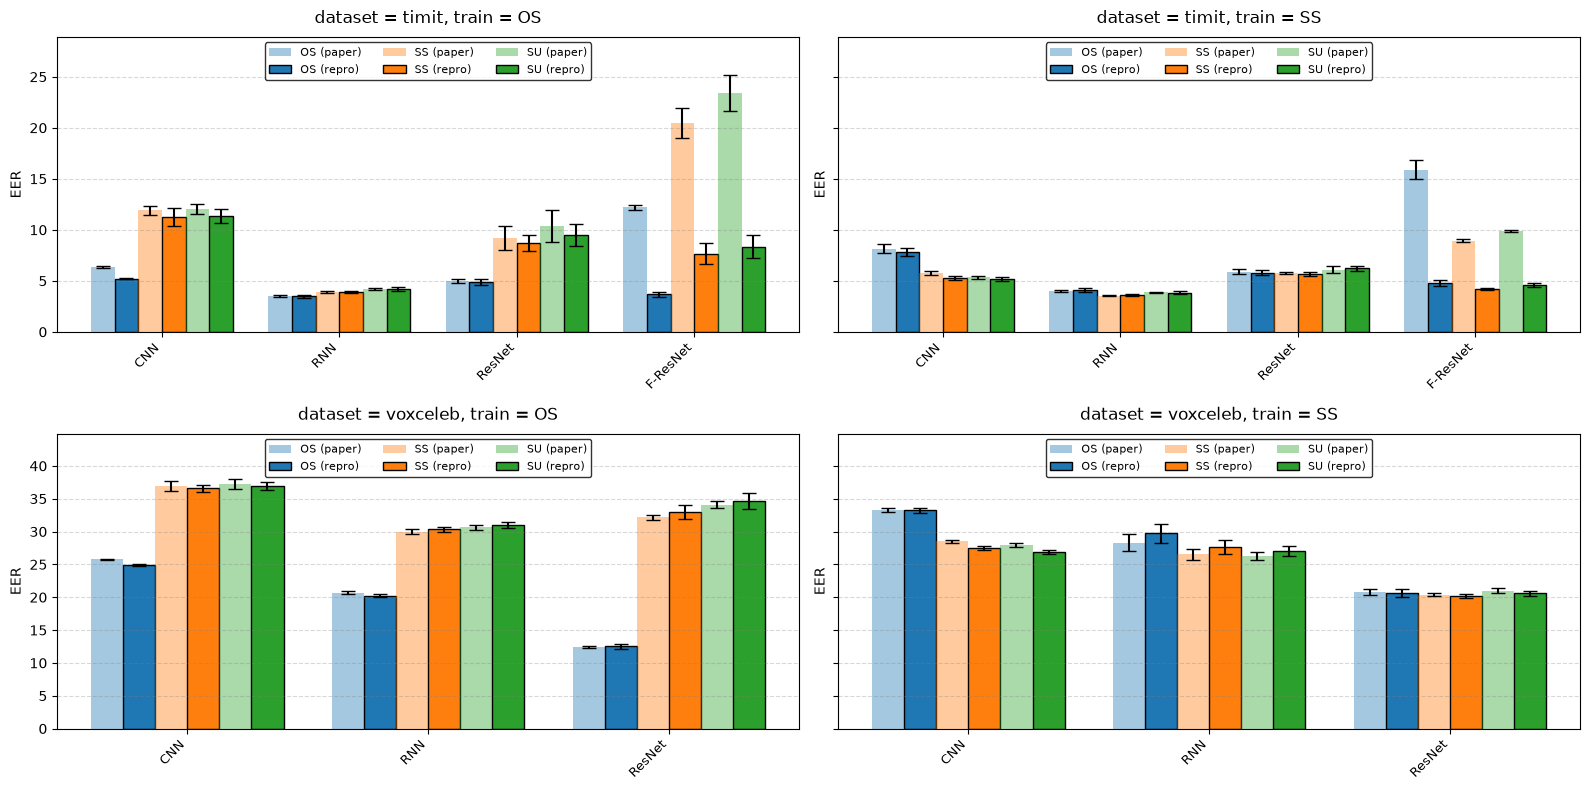

In [2]:
#| label: figure-paper-vs-reproduction
#| caption: Experiment reproduction compared to the original paper results (@doi:10.1016/j.patrec.2024.03.016) for TIMIT and VoxCeleb datasets.
plots.paper_vs_repro()

# Evaluating the Conformer Architecture

@figure-conformer-vs-others-voxceleb shows the different EERs on the VoxCeleb dataset of each architecture trained on OS and tested on OS and SS data. The EER seems to depend on the architecture complexity, whereas the Conformer architecture (@doi:10.48550/arXiv.2005.08100) scores the lowest EER on OS data.

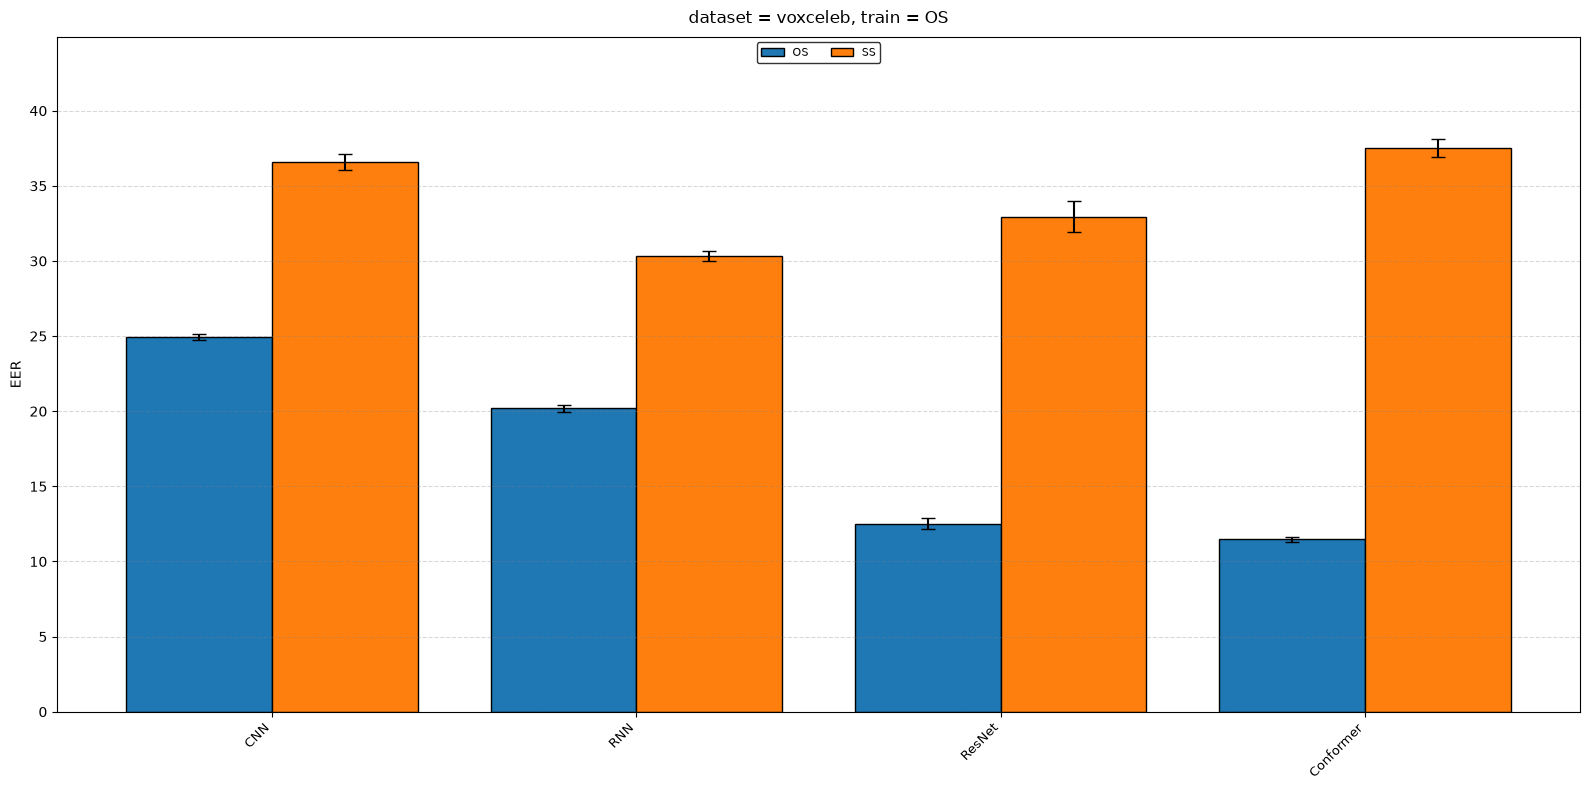

In [3]:
#| label: figure-conformer-vs-others-voxceleb
#| caption: EER depends on architecture complexity; The most complex architecture (Conformer) scores the lowest EER on OS data.
plots.abs_eer(comparison_type='test_strategy')

The test results of OS-trained architectures show individual relative EER difference when tested with OS and SS data. However, the magnitude of the observed relative differences is proportional to the corresponding's architecture complexity. This leads to the conclusion, that a more complex architecture tends to be better at exploiting SST information (@figure-relative-difference-voxceleb-os-vs-ss).

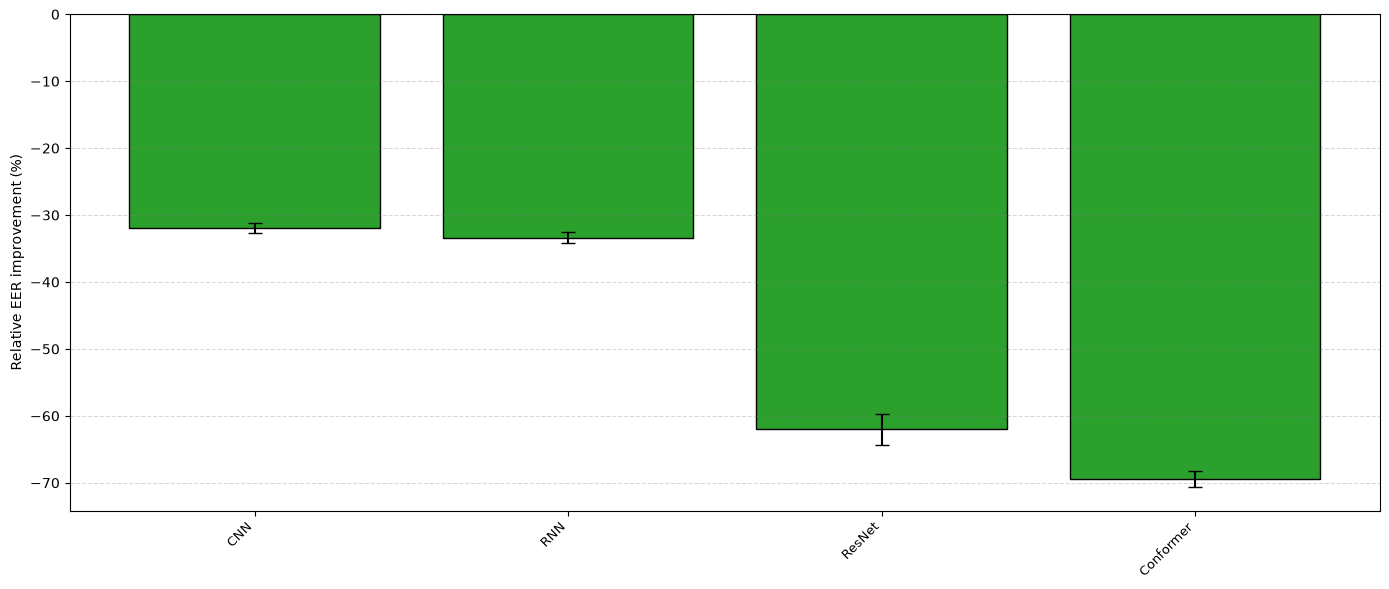

In [4]:
#| label: figure-relative-difference-voxceleb-os-vs-ss
#| caption: Relative difference of OS compared to SS results for each architecture trained on OS data. The Conformer shows the biggest relative difference ($-69.44 \% \pm 1.20$).
plots.relative_eer(comparison_type='test_strategy')

We expect a "result in one order of magnitude lower error rates" @doi:10.1016/j.patrec.2024.03.016 for any architecture fully exploiting SST information. One order of magnitude is a relative difference of $-90 \%$ when comparing the resulting EER of SS and OS data (if the architecture was trained on OS data). Even though our best result is quite good, the Conformer's relative EER difference is still below expectation ($-69.44 \% \pm 1.20$, @figure-relative-difference-voxceleb-os-vs-ss).

# Justification for Out-of-Distribution Testing

Arguably the main reason why architectures trained on OS data perform bad on SS data is because of the distribution shift – and not because they are ignoring SST information. @figure-train-test-in-distribution shows the training and test results of the different architectures within their corresponding data distribution of VoxCeleb. Again we see an improvement of the EER proportionally to the architecture complexity. And $EER(train=OS, test=OS)$ is lower than $EER(train=SS, test=SS)$ across all architectures.

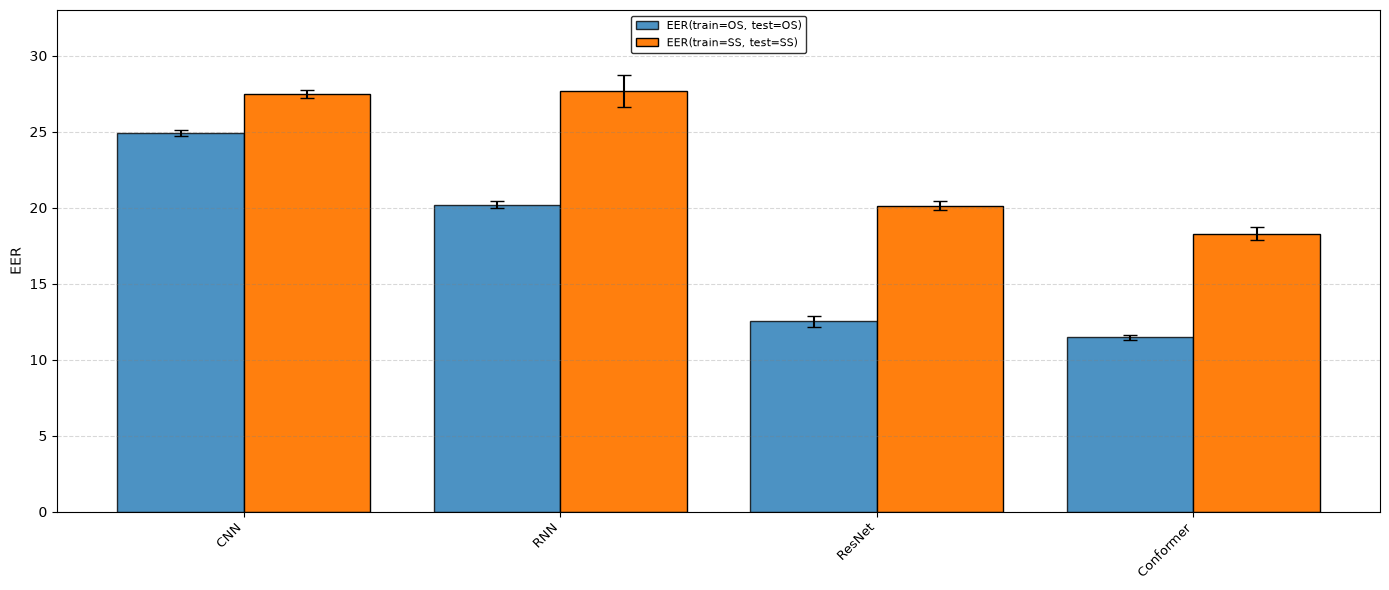

In [5]:
#| label: figure-train-test-in-distribution
#| caption: Train and test results for the different architectures within data distributions; For each architecture $EER(train=OS, test=OS)$ is lower than $EER(train=SS, test=SS)$.
plots.abs_eer(comparison_type='training_strategy')

@figure-relative-difference-voxceleb-in-distribution shows the relative difference between the two in-distribution EER test results. Notably, the difference between ResNet and the Conformer architecture are very similar. However, it is unclear how to interpret these results as the expected EER improvement claim (@doi:10.1016/j.patrec.2024.03.016) origins from a study conducted with human participants (@10.1145/1631272.1631300). And because the human brain is trained on OS data we argue that the relative difference of in-distribution error rates are not a good metric for SST exploitation.

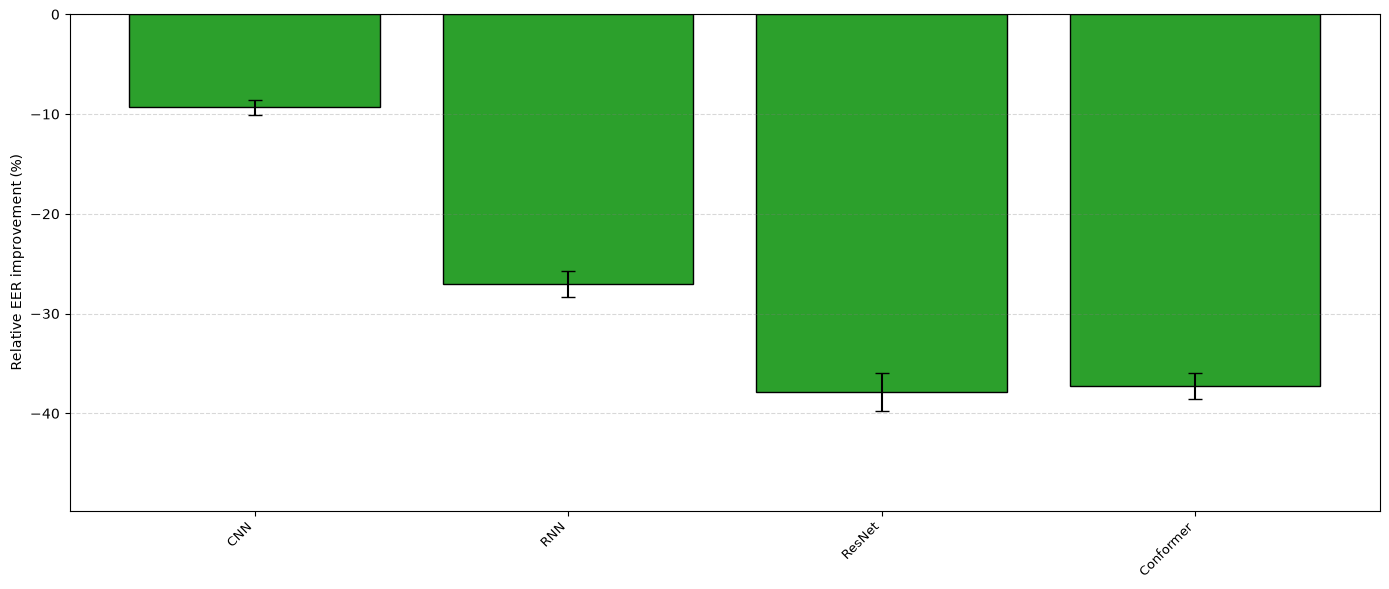

In [6]:
#| label: figure-relative-difference-voxceleb-in-distribution
#| caption: Relative difference for in-distribution error rates $EER(train=SS, test=SS)$ and $EER(train=OS, train=OS)$
plots.relative_eer(comparison_type='training_strategy')